# Task 1
Дослідіть вплив функцій активації на результати моделі.
* Згенеруйте синтетичні дані для регресії за допомогою функції make_regression (2000 рядків, 10 ознак, noise=10, random_state=42).
* Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
* Послідовно застосуйте різні функції активації: ReLU, Tanh, LeakyReLU, Swish.
* Для кожної активації розрахуйте MAE і R² на тестовій вибірці.
* Оформіть результати в таблиці:

In [67]:
from sklearn.datasets import make_regression

In [68]:
X, y = make_regression(n_samples=2000, n_features=10, noise=10, random_state=42)
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

import torch
xtrain = torch.tensor(xtrain, dtype=torch.float32)
xtest = torch.tensor(xtest, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.float32).reshape(-1, 1) * 0.01
ytest = torch.tensor(ytest, dtype=torch.float32).reshape(-1, 1) * 0.01
xtrain[:5]

tensor([[ 2.4155,  0.8898, -1.2309,  0.7315, -0.7065, -1.6734,  0.7652, -1.3145,
          0.8829,  1.1793],
        [-0.4340, -0.2455,  0.9917, -0.4796, -1.0463, -1.7330, -0.3643,  0.2105,
         -0.9889,  0.2208],
        [-1.2429,  1.2392,  0.3792,  1.4135, -1.8120,  0.0235,  1.3326,  0.0844,
         -0.3181,  0.1518],
        [ 0.0343,  0.4951,  0.6052, -1.0827,  0.4172,  1.6766, -0.0057, -0.5786,
          2.1690,  0.1295],
        [-0.6669,  0.1663, -0.6088, -0.1148, -0.8104,  0.1573, -1.5061, -0.0400,
         -0.1620,  1.8046]])

In [69]:
import torch.nn as nn
activators = {
    'Sigmoid': nn.Sigmoid(),
    'ReLU': nn.ReLU(),
    'Tanh': nn.Tanh(),
    'LeakyReLU': nn.LeakyReLU(),
    'SiLU': nn.SiLU(),
    'Swish': nn.SiLU(),
}

In [70]:
class Mlp(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, output_size=1, activation='ReLU'):
        super(Mlp, self).__init__()
        self.activation = activators.get(activation, None)
        if self.activation is None:
            raise ValueError(f"Undefined activator '{activation}'")
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size),
        )
    def forward(self, x, mode='test'):
        return self.layers(x)

In [71]:
def train_model(model, X, y, epochs=1000, lr=0.01):
    criterion = nn.functional.mse_loss
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = [*range(epochs)]
    for epoch in range(epochs):
        output = model(X, 'train')
        loss = criterion(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses[epoch] = loss.item()
    return losses

In [72]:
mlps = {k: Mlp(activation=k) for k in activators.keys()}
mlps

{'Sigmoid': Mlp(
   (activation): Sigmoid()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): Sigmoid()
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 'ReLU': Mlp(
   (activation): ReLU()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): ReLU()
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 'Tanh': Mlp(
   (activation): Tanh()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): Tanh()
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 'LeakyReLU': Mlp(
   (activation): LeakyReLU(negative_slope=0.01)
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): LeakyReLU(negative_slope=0.01)
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 'SiLU': Mlp(
   (activation): SiLU()
   (layers): Sequential(
     (0): Linear(in_features=10, ou

In [73]:
def train_models_set(mlps, xtrain, ytrain):
    losses = {}
    predictions = {}
    for k, mlp in mlps.items():
        losses[k] = train_model(mlp, xtrain, ytrain)
        with torch.no_grad():
            predictions[k] = mlp(xtest)
    return losses, predictions

In [74]:
losses, predictions = train_models_set(mlps, xtrain, ytrain)
print(*zip(*(predictions[k][:5] for k in mlps.keys() ), ytest[:5]), sep='\n')

(tensor([2.6662]), tensor([2.4412]), tensor([2.8186]), tensor([2.6220]), tensor([2.5272]), tensor([2.4675]), tensor([2.4752]))
(tensor([1.9227]), tensor([2.2494]), tensor([1.7938]), tensor([1.5311]), tensor([2.0658]), tensor([2.1633]), tensor([2.1351]))
(tensor([-2.4506]), tensor([-2.2915]), tensor([-2.4080]), tensor([-2.3831]), tensor([-2.2883]), tensor([-2.3548]), tensor([-2.3298]))
(tensor([0.4018]), tensor([0.5423]), tensor([0.4135]), tensor([0.3426]), tensor([0.3666]), tensor([0.3163]), tensor([0.4227]))
(tensor([1.9791]), tensor([1.9720]), tensor([1.9660]), tensor([1.9947]), tensor([1.9147]), tensor([1.8995]), tensor([1.7829]))


In [75]:
from IPython.display import Markdown as md
import sklearn.metrics as sm

def score_table(ytest, predictions):
    return md("\n".join((
        "|Activation|MAE|R²|",
        "|-|-|-|",
        *(f"|{k}|{sm.mean_absolute_error(ytest, v)}|{sm.r2_score(ytest, v)}|" for k, v in predictions.items())
    )))

In [76]:
score_table(ytest, predictions)

|Activation|MAE|R²|
|-|-|-|
|Sigmoid|0.1347377747297287|0.9906607866287231|
|ReLU|0.1499962955713272|0.9902031421661377|
|Tanh|0.1473369151353836|0.9893510937690735|
|LeakyReLU|0.1338464766740799|0.992152750492096|
|SiLU|0.09374114871025085|0.9964302182197571|
|Swish|0.09158887714147568|0.9963874816894531|

In [77]:
import matplotlib.pyplot as plt

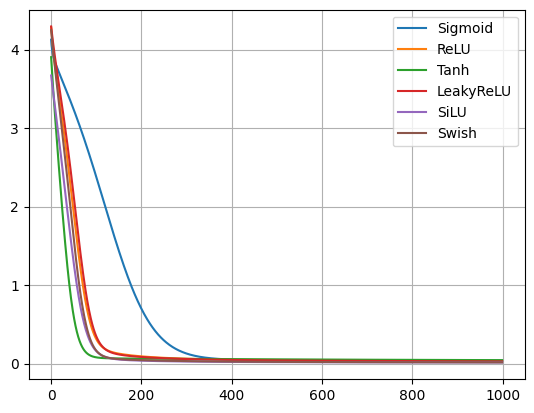

In [78]:
def graph(losses):
    _, ax = plt.subplots()
    for k, v in losses.items():
        ax.plot(v, label=k)
    plt.legend()
    ax.grid()
    plt.show()

graph(losses)

# Завдання 2
Додайте Dropout і проаналізуйте вплив регуляризації.
* Використовуйте ту саму архітектуру MLP.
* Додайте шар torch.nn.Dropout(p=0.3) після прихованого шару.
* Порівняйте результати до і після застосування Dropout за MAE і R².
* Зробіть висновок: чи допомагає Dropout уникнути перенавчання?

In [79]:
class MlpDropout(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, output_size=1, activation='ReLU'):
        super(MlpDropout, self).__init__()
        self.activation = activators.get(activation, None)
        if self.activation is None:
            raise ValueError(f"Undefined activator '{activation}'")
        self.hidden = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(p=0.3)
        self.output = nn.Linear(hidden_size, output_size)
        
    def forward(self, x, mode='test'):
        x = self.hidden(x)
        x = self.activation(x)
        if mode != 'test':
            x = self.dropout(x)
        x = self.output(x)
        return x

In [80]:
mlps_d = {k: MlpDropout(activation=k) for k in activators.keys()}
losses_d, predictions_d = train_models_set(mlps_d, xtrain, ytrain)
print(*zip(*(predictions_d[k][:5] for k in mlps_d.keys() ), ytest[:5]), sep='\n')
score_table(ytest, predictions_d)

(tensor([2.3490]), tensor([2.4819]), tensor([2.5203]), tensor([2.3716]), tensor([2.4709]), tensor([2.4156]), tensor([2.4752]))
(tensor([1.8213]), tensor([1.6930]), tensor([1.6743]), tensor([1.8281]), tensor([1.8617]), tensor([1.9988]), tensor([2.1351]))
(tensor([-2.1691]), tensor([-2.2781]), tensor([-2.3210]), tensor([-2.1870]), tensor([-2.2745]), tensor([-2.2743]), tensor([-2.3298]))
(tensor([0.3599]), tensor([0.3105]), tensor([0.4067]), tensor([0.2605]), tensor([0.2958]), tensor([0.3628]), tensor([0.4227]))
(tensor([1.7577]), tensor([1.8384]), tensor([1.9221]), tensor([1.9592]), tensor([1.8109]), tensor([1.8478]), tensor([1.7829]))


|Activation|MAE|R²|
|-|-|-|
|Sigmoid|0.19581694900989532|0.9723487496376038|
|ReLU|0.14019209146499634|0.9912898540496826|
|Tanh|0.1348794847726822|0.9884512424468994|
|LeakyReLU|0.13059675693511963|0.9926036596298218|
|SiLU|0.11060959100723267|0.9948419332504272|
|Swish|0.10747081786394119|0.9951630234718323|

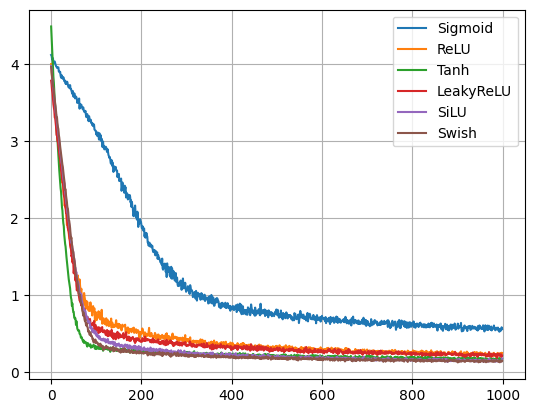

In [81]:
graph(losses_d)

In [82]:
# Dropout помогает избежать переобучения в заданных корекций от входных данных, скрытых и выходящих, за счет большего количества объема нейронов.
# Поэтому на графике видны колебания значений

# Task 3
Додайте Batch Normalization для стабілізації навчання.
* Використовуйте шар torch.nn.BatchNorm1d після лінійного шару.
* Навчіть модель і побудуйте графік функції втрат за епохами.
* Порівняйте розкид loss з попередніми експериментами.

In [83]:
class MlpBatch(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, output_size=1, activation='ReLU'):
        super(MlpBatch, self).__init__()
        self.activation = activators.get(activation, None)
        if self.activation is None:
            raise ValueError(f"Undefined activator '{activation}'")
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size),
        )
        
    def forward(self, x, mode='test'):
        x = self.layers(x)
        return x

In [84]:
mlps_b = {k: MlpBatch(activation=k) for k in activators.keys()}
losses_b, predictions_b = train_models_set(mlps_b, xtrain, ytrain)
print(*zip(*(predictions_b[k][:5] for k in mlps_b.keys() ), ytest[:5]), sep='\n')
score_table(ytest, predictions_b)

(tensor([2.4320]), tensor([2.1487]), tensor([2.7356]), tensor([2.2409]), tensor([2.2481]), tensor([2.2015]), tensor([2.4752]))
(tensor([1.5630]), tensor([1.8480]), tensor([1.4022]), tensor([1.3894]), tensor([1.5575]), tensor([1.4602]), tensor([2.1351]))
(tensor([-2.7494]), tensor([-2.7182]), tensor([-2.7688]), tensor([-2.6767]), tensor([-2.5974]), tensor([-2.6714]), tensor([-2.3298]))
(tensor([0.0524]), tensor([-0.1741]), tensor([0.1940]), tensor([-0.0781]), tensor([0.0207]), tensor([0.0081]), tensor([0.4227]))
(tensor([1.7479]), tensor([1.6578]), tensor([1.7551]), tensor([1.7520]), tensor([1.5591]), tensor([1.6317]), tensor([1.7829]))


|Activation|MAE|R²|
|-|-|-|
|Sigmoid|0.3148120045661926|0.9654618501663208|
|ReLU|0.29876887798309326|0.9727799892425537|
|Tanh|0.3480457663536072|0.9533359408378601|
|LeakyReLU|0.28692826628685|0.9741336703300476|
|SiLU|0.29290151596069336|0.9742228388786316|
|Swish|0.29291048645973206|0.974214494228363|

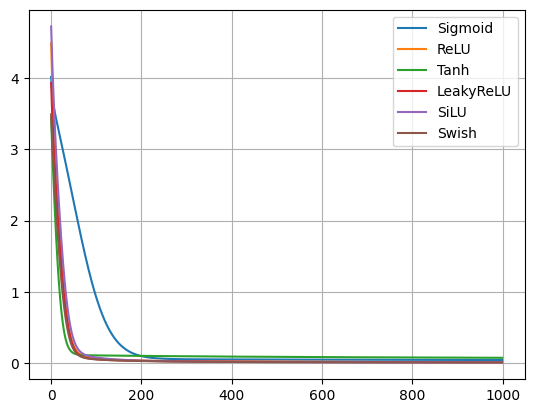

In [85]:
graph(losses_b)

In [86]:
# При использовании шара Batch обучение идет намного эффективнее чем с прошлыми эксперементами, при этом переобучения не происходит

In [89]:
class MlpDropoutBatch(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, output_size=1, activation='ReLU'):
        super(MlpDropoutBatch, self).__init__()
        self.activation = activators.get(activation, None)
        if self.activation is None:
            raise ValueError(f"Undefined activator '{activation}'")
        self.hidden = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(p=0.3)
        self.output = nn.Linear(hidden_size, output_size)
        self.batch = nn.BatchNorm1d(hidden_size)
        
    def forward(self, x, mode='test'):
        x = self.hidden(x)
        x = self.batch(x)
        x = self.activation(x)
        if mode != 'test':
            x = self.dropout(x)
        x = self.output(x)
        return x

In [90]:
mlps_db = {k: MlpDropoutBatch(activation=k) for k in activators.keys()}
losses_db, predictions_db = train_models_set(mlps_db, xtrain, ytrain)
print(*zip(*(predictions_db[k][:5] for k in mlps_db.keys() ), ytest[:5]), sep='\n')
score_table(ytest, predictions_db)

(tensor([2.1004]), tensor([2.0491]), tensor([2.5478]), tensor([2.1896]), tensor([2.1857]), tensor([2.2023]), tensor([2.4752]))
(tensor([1.4976]), tensor([1.3304]), tensor([1.4937]), tensor([1.6019]), tensor([1.6067]), tensor([1.4450]), tensor([2.1351]))
(tensor([-2.5678]), tensor([-2.4607]), tensor([-2.7730]), tensor([-2.5079]), tensor([-2.5579]), tensor([-2.5882]), tensor([-2.3298]))
(tensor([0.0322]), tensor([0.0087]), tensor([0.0526]), tensor([0.0529]), tensor([0.0995]), tensor([0.0100]), tensor([0.4227]))
(tensor([1.6319]), tensor([1.5780]), tensor([1.7760]), tensor([1.5305]), tensor([1.5627]), tensor([1.5490]), tensor([1.7829]))


|Activation|MAE|R²|
|-|-|-|
|Sigmoid|0.3622915744781494|0.9499975442886353|
|ReLU|0.2919965088367462|0.9721406698226929|
|Tanh|0.34304237365722656|0.952860951423645|
|LeakyReLU|0.2996009588241577|0.9717528223991394|
|SiLU|0.29225513339042664|0.9739959239959717|
|Swish|0.29096710681915283|0.9740846157073975|

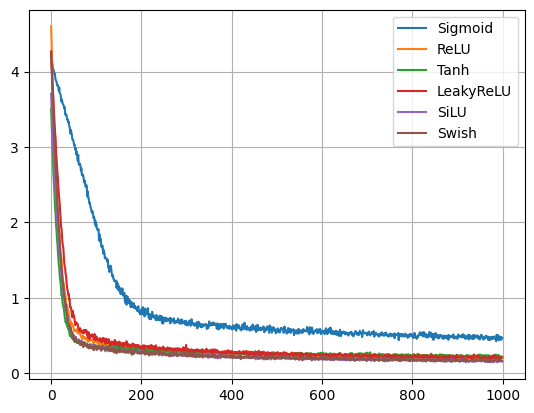

In [91]:
graph(losses_db)